In [1]:
from utils import ComplexRadar, plot_parallel_coordinates_ci
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dic = {
    "Cal": {
        "MCMC": [0.1, 0.2, 0.15, 0.1],
        "VI": [0.3, 0.4, 0.35, 0.3],
        "SSVS": [0.5, 0.6, 0.55, 0.5],
        "QR":  [0.8, 0.9, 0.85, 0.8],
    },
    "Cov": {
        "MCMC": [0.9, 0.95, 0.92, 0.91],
        "VI": [0.8, 0.85, 0.82, 0.81],
        "SSVS": [0.7, 0.75, 0.72, 0.71],
        "QR":  [0.6, 0.65, 0.62, 0.61],
    },
    "mCPRS": {
        "MCMC": [0.05, 0.06, 0.055, 0.05],
        "VI": [0.15, 0.16, 0.155, 0.15],
        "SSVS": [0.25, 0.26, 0.255, 0.25],
        "QR":  [0.35, 0.36, 0.355, 0.35],
    },
    "Width": {
        "MCMC": [5, 10, 6, 6],
        "VI": [4, 5, 6, 7],
        "SSVS": [3, 8, 9, 10],
        "QR":  [12, 15, 5, 3],
    }
}


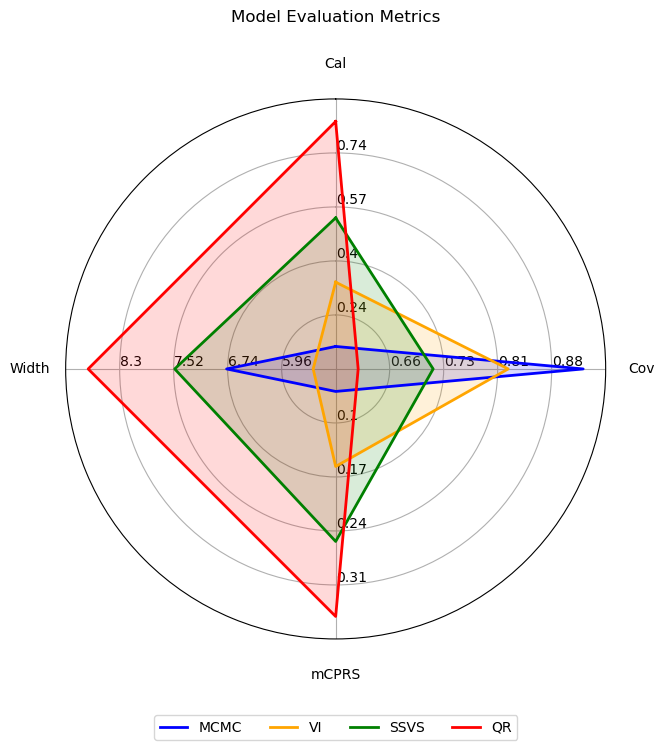

In [3]:
metrics = list(dic.keys())
models = list(dic[metrics[0]].keys())

data_matrix = {model: [np.mean(dic[metric][model]) for metric in metrics] for model in models}

ranges = []
for i, metric in enumerate(metrics):
    vals = [data_matrix[m][i] for m in models]
    vmin, vmax = min(vals), max(vals)
    if vmin == vmax:
        ranges.append((vmin - 0.1, vmax + 0.1))
    else:
        padding = (vmax - vmin) * 0.1
        ranges.append((vmin - padding, vmax + padding))

fig = plt.figure(figsize=(6, 6))
radar = ComplexRadar(fig, metrics, ranges)

colors = ['blue', 'orange', 'green', 'red']

for i, model in enumerate(models):
    radar.plot(data_matrix[model], label=model, color=colors[i], linewidth=2)
    radar.fill(data_matrix[model], facecolor=colors[i], alpha=0.15)

radar.ax.set_title("Model Evaluation Metrics", pad=25)
radar.use_legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(models))
plt.show()

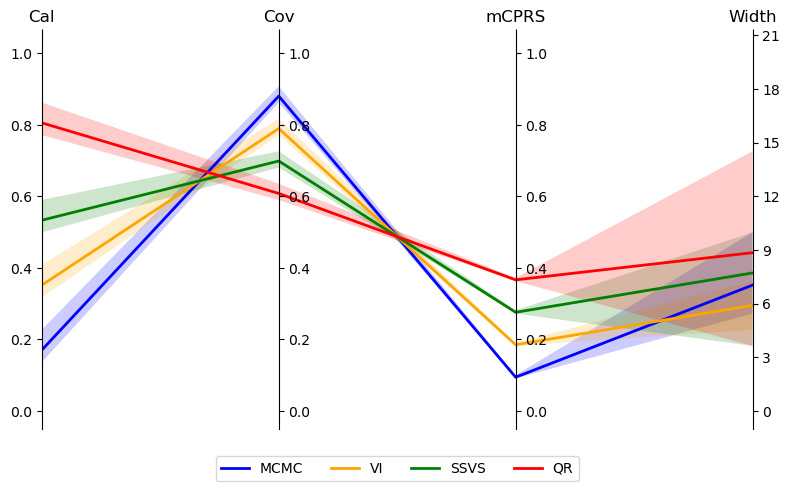

In [4]:
bounds={"Cal":[0,1],
        "Cov":[0,1],
        "mCPRS":[0,1],
        "Width":[0,20]
}
plot_parallel_coordinates_ci(dic, bounds)